Agentic RAG

In [1]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage
from typing import TypedDict, Annotated, List
from langchain_core.documents import Document

c:\Users\ASUS\.conda\envs\graph-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

Preprocess Data

In [4]:
loader = PyPDFLoader("attention.pdf")
chunks = loader.load()

text_splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap = 100)
docs = text_splitter.split_documents(chunks)

In [5]:
embeddings = HuggingFaceEmbeddings(
        model_name="sentence-transformers/all-MiniLM-L6-v2"
    )

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18504\2131500445.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


In [6]:
db = FAISS.from_documents(docs, embeddings)
retriever = db.as_retriever(k=5)

In [7]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="llama-3.1-8b-instant")

In [8]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [9]:
rag_prompt = ChatPromptTemplate.from_template(
    """Answer the question based only on the context below.

    Context:
    {context}

    Question: {question}
    """
)

In [10]:
rag_chain = (
    rag_prompt
    | llm
    | StrOutputParser()
)

Retrival Grader

In [11]:
from pydantic import BaseModel, Field

In [ ]:
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

In [ ]:
structured_llm_grader = llm.with_structured_output(GradeDocuments)

In [14]:
system = """You are a grader checking if a document is relevant to a user’s question.The check has to be done very strictly..  
If the document has words or meanings related to the question, mark it as relevant.  
Give a simple 'yes' or 'no' answer to show if the document is relevant or not."""
    
grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

In [ ]:
grader_chain = (
    grade_prompt
    | llm
    | StrOutputParser()
)

In [15]:
my_retrieval_grader = grade_prompt | structured_llm_grader

State

In [16]:
class GraphState(TypedDict):
    question: str
    documents: List[Document]
    generation: str

Nodes Definations

In [17]:
def retrieve(state: GraphState):
    question = state["question"]
    documents = retriever.invoke(question)
    return {"documents": documents}

In [18]:
def grade_documents(state: GraphState):
    question = state["question"]
    documents = state["documents"]

    filtered_docs = []

    for doc in documents:
        score = my_retrieval_grader.invoke({
            "document": doc.page_content,
            "question": question
        })

        if score.binary_score.lower() == "yes":
            filtered_docs.append(doc)

    return {"documents": filtered_docs}

In [19]:
def generate(state: GraphState):
    question = state["question"]
    documents = state["documents"]

    context = "\n\n".join([doc.page_content for doc in documents])

    generation = rag_chain.invoke({
        "context": context,
        "question": question
    })

    return {"generation": generation}

Conditional Edge

In [20]:
def decide_to_generate(state: GraphState):
    if len(state["documents"]) == 0:
        return "no_docs"
    return "generate"

GRAPH WorkFlow

In [21]:
from langgraph.graph import StateGraph, END

workflow = StateGraph(GraphState)

# Add nodes
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)

# Define edges
workflow.set_entry_point("retrieve")
workflow.add_edge("retrieve", "grade_documents")

workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "generate": "generate",
        "no_docs": END,
    },
)

workflow.add_edge("generate", END)


In [22]:
app = workflow.compile()

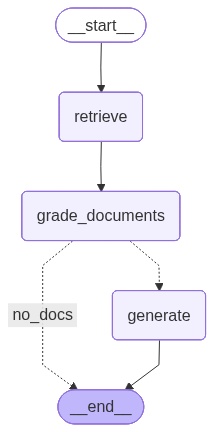

In [23]:
app

INFERENCE

In [ ]:
# llm.with_structured_output is compatible with openai model
response = app.invoke({
    "question": "What is attention mechanism?"
})

print(response["generation"])